In [ ]:
import numpy as np

def aharoni_Nz(a, b, c):
    # half-dimensions along x, y, z; returns Nzz for a rectangular prism
    # Aharoni (1998), demag factor along c-axis
    a, b, c = a/2, b/2, c/2
    r = np.sqrt(a**2 + b**2 + c**2)
    ab = np.sqrt(a**2 + b**2); bc = np.sqrt(b**2 + c**2); ac = np.sqrt(a**2 + c**2)
    F = ( (b**2 - c**2)/(2*b*c) * np.log((r - a)/(r + a))
        + (a**2 - c**2)/(2*a*c) * np.log((r - b)/(r + b))
        + b/(2*c) * np.log((ab + a)/(ab - a))
        + a/(2*c) * np.log((ab + b)/(ab - b))
        + c/(2*a) * np.log((bc - b)/(bc + b))
        + c/(2*b) * np.log((ac - a)/(ac + a))
        + 2*np.arctan2(a*b, c*r)
        + (a**3 + b**3 - 2*c**3)/(3*a*b*c)
        + (a**2 + b**2 - 2*c**2)/(3*a*b*c)*r
        + c/(a*b)*(ac + bc)
        - (ab**3 + bc**3 + ac**3)/(3*a*b*c) )
    return F/np.pi

Lx = Ly = 80e-9
tFL = 0.9e-9
Nzz = aharoni_Nz(Lx, Ly, tFL)          # z = out-of-plane (thin axis)
Nxx = aharoni_Nz(tFL, Ly, Lx)          # permute so the long axis is "c"
Nyy = aharoni_Nz(Lx, tFL, Ly)
print(f"Nxx={Nxx:.5f}  Nyy={Nyy:.5f}  Nzz={Nzz:.5f}  sum={Nxx+Nyy+Nzz:.5f}")

Nxx=0.01868  Nyy=0.01868  Nzz=0.96264  sum=1.00000


Saving 16. SOT T Threshold corrected.txt to 16. SOT T Threshold corrected.txt
Dropped 255 rows below 300 K; 561 rows remain over T = 300.0-400.0 K
   JHM    T        mz
5  0.0  300  0.983550
6  0.0  310  0.984853
7  0.0  320  0.986029
8  0.0  330  0.987093
9  0.0  340  0.988058

mz range: -0.992 to 0.992  (expect roughly -1 .. +1)


  T     Jc_onset       Jc_det
300 6.000000e+11 3.000000e+12
310 6.000000e+11 1.000000e+12
320 6.000000e+11 6.000000e+11
330 6.000000e+11 6.000000e+11
340 6.000000e+11 6.000000e+11
350 6.000000e+11 6.000000e+11
360 6.000000e+11 6.000000e+11
370 8.000000e+11 8.000000e+11
380 8.000000e+11 8.000000e+11
390 8.000000e+11 8.000000e+11
400 8.000000e+11 8.000000e+11



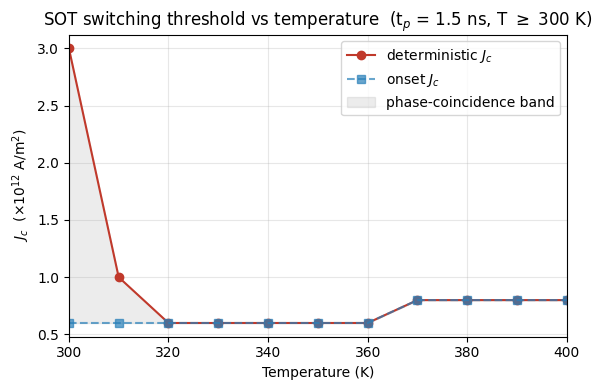

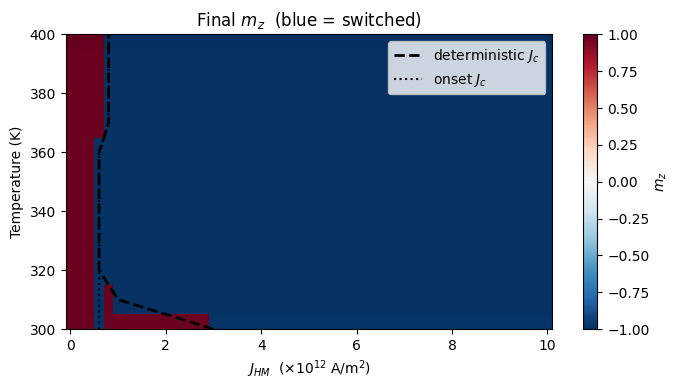

Saved: Jc_vs_T.csv, Jc_vs_T.png, switching_map.png
T
300    0.983550
310    0.984853
320    0.986029
330    0.987093
340    0.988058
350    0.988935
360    0.989736
370    0.990468
380    0.991138
390    0.991753
400    0.992318
Name: mz, dtype: float64


In [ ]:
# -15mT, correct Nxx Nyy Nzz
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

T_MIN = 300.0

# ------------------------------------------------------------------ load
uploaded = files.upload()
fname = list(uploaded.keys())[0]

# COMSOL export has 4 columns: JHM, T, Time, mz  -> keep JHM, T, mz (drop Time)
df = pd.read_csv(fname, comment='%', sep=r'\s+', header=None)
df = df.iloc[:, [0, 1, 3]].copy()
df.columns = ['JHM', 'T', 'mz']
df = df.apply(pd.to_numeric, errors='coerce').dropna()

# ------------------------------------------------------ restrict to T >= 300 K
n_before = len(df)
df = df[df['T'] >= T_MIN].copy()
n_dropped = n_before - len(df)
if len(df) == 0:
    raise ValueError(f"No rows at T >= {T_MIN} K -- check the export.")
print(f"Dropped {n_dropped} rows below {T_MIN:.0f} K; "
      f"{len(df)} rows remain over T = {df['T'].min():.1f}-{df['T'].max():.1f} K")

print(df.head())
print(f"\nmz range: {df['mz'].min():.3f} to {df['mz'].max():.3f}  "
      f"(expect roughly -1 .. +1)\n")

# ------------------------------------------------- switching flag per T
# Initial state inferred from the lowest-J row of each temperature (should
# be unswitched). Switched = mz has flipped sign AND settled past |0.5|.
parts = []
for T, g in df.groupby('T'):
    g = g.sort_values('JHM').copy()
    ref = np.sign(g['mz'].iloc[0])
    g['switched'] = (np.sign(g['mz']) != ref) & (g['mz'].abs() > 0.5)
    parts.append(g)
df = pd.concat(parts, ignore_index=True)

# --------------------------------------------- threshold extraction
# Onset Jc      : first J that switches at all (edge of the phase-coincidence band)
# Deterministic : first J of the unbroken switched tail (all higher J switch)
def thresholds(g):
    g = g.sort_values('JHM').reset_index(drop=True)
    sw = g['switched'].values
    J = g['JHM'].values

    onset = J[sw][0] if sw.any() else np.nan

    if not sw.any():
        det = np.nan
    else:
        fails = np.where(~sw)[0]
        if len(fails) == 0:
            det = J[0]                       # switches everywhere
        elif fails[-1] == len(sw) - 1:
            det = np.nan                     # no stable switched tail
        else:
            det = J[fails[-1] + 1]           # first J of unbroken tail
    return onset, det

records = []
for T, g in df.groupby('T'):
    onset, det = thresholds(g)
    if not np.isnan(onset) and np.isnan(det):
        print(f"  note: T={T:.0f} K switches at onset {onset:.2e} "
              f"but never reaches a stable deterministic tail")
    records.append({'T': T, 'Jc_onset': onset, 'Jc_det': det})

jc = pd.DataFrame(records).sort_values('T').reset_index(drop=True)
print("\n" + jc.to_string(index=False) + "\n")

# --------------------------------------------------------- Plot 1: Jc(T)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(jc['T'], jc['Jc_det']/1e12,   'o-', color='#c0392b', label='deterministic $J_c$')
ax.plot(jc['T'], jc['Jc_onset']/1e12, 's--', color='#2980b9', alpha=0.7, label='onset $J_c$')
ax.fill_between(jc['T'], jc['Jc_onset']/1e12, jc['Jc_det']/1e12,
                color='gray', alpha=0.15, label='phase-coincidence band')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'$J_c$  (×10$^{12}$ A/m$^2$)')
ax.set_title(f'SOT switching threshold vs temperature  '
             f'(t$_p$ = 1.5 ns, T $\\geq$ {T_MIN:.0f} K)')
ax.set_xlim(T_MIN, df['T'].max())
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('Jc_vs_T.png', dpi=150); plt.show()

# ------------------------------------------------ Plot 2: switching map
piv = df.pivot_table(index='T', columns='JHM', values='mz')
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.pcolormesh(piv.columns/1e12, piv.index, piv.values,
                   shading='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.plot(jc['Jc_det']/1e12,   jc['T'], 'k--', lw=2, label='deterministic $J_c$')
ax.plot(jc['Jc_onset']/1e12, jc['T'], 'k:',  lw=1.5, label='onset $J_c$')
ax.set_xlabel(r'$J_{HM}$  (×10$^{12}$ A/m$^2$)')
ax.set_ylabel('Temperature (K)')
ax.set_title('Final $m_z$  (blue = switched)')
ax.set_ylim(T_MIN, df['T'].max())
ax.legend(loc='upper right')
fig.colorbar(im, label='$m_z$')
plt.tight_layout(); plt.savefig('switching_map.png', dpi=150); plt.show()

jc.to_csv('Jc_vs_T.csv', index=False)
print("Saved: Jc_vs_T.csv, Jc_vs_T.png, switching_map.png")
lowJ = df.sort_values('JHM').groupby('T').first()['mz']
print(lowJ)